In [1]:
import pandas as pd
import numpy as np
import prince


In [2]:
df = pd.read_excel("medical_insurance.xlsx")


In [3]:
df.head()
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [4]:
df["smoker"] = df["smoker"].fillna("None")




In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [9]:
df.count

<bound method DataFrame.count of        person_id  age     sex   region urban_rural    income     education  \
0          75722   52  Female    North    Suburban   22700.0     Doctorate   
1          80185   79  Female    North       Urban   12800.0         No HS   
2          19865   68    Male    North       Rural   40700.0            HS   
3          76700   15    Male    North    Suburban   15600.0  Some College   
4          92992   53    Male  Central    Suburban   89600.0     Doctorate   
...          ...  ...     ...      ...         ...       ...           ...   
99995       6266   50    Male     West       Urban  127200.0         No HS   
99996      54887   42    Male     East    Suburban   21600.0            HS   
99997      76821   41    Male     West       Rural   81900.0            HS   
99998        861   51  Female    South       Urban   43400.0     Doctorate   
99999      15796   44  Female    South       Rural   43700.0  Some College   

      marital_status employmen

In [ ]:

import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt

# 1.1. Grupo de edad
df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[-1, 23, 65, 120],
    labels=["joven", "adulto", "mayor"]
)
print("Frecuencias grupo_edad:")
print(df["grupo_edad"].value_counts(dropna=False), "\n")

# 1.2. Número de patologías crónicas
df['patologias_cronicas'] = pd.cut(
    df['chronic_count'],
    bins=[-1, 0, 6],
    labels=['ninguna', 'alguna']
)
print("Frecuencias patologias_cronicas:")
print(df['patologias_cronicas'].value_counts(dropna=False), "\n")

# 1.3. Hospitalizaciones últimos 3 años
df['hospitalizado'] = pd.cut(
    df['hospitalizations_last_3yrs'],
    bins=[-1, 0, 100],
    labels=['no', 'si']
)
print("Frecuencias hospitalizado:")
print(df['hospitalizado'].value_counts(dropna=False), "\n")

# 1.4. Coste anual (terciles)
df['grupo_coste'] = pd.cut(
    df['annual_medical_cost'],
    bins=[-1, 3000, 7000, df['annual_medical_cost'].max()],
    labels=['bajo_coste', 'medio_coste', 'alto_coste']
)
print("Frecuencias grupo_coste:")
print(df['grupo_coste'].value_counts(dropna=False), "\n")

# 1.5. Variables binarias a categórico
for col in ['cancer_history', 'had_major_procedure', 'is_high_risk',
            'smoker', 'mental_health', 'plan_type']:
    df[col] = df[col].astype('category')



Frecuencias grupo_edad:
grupo_edad
adulto    80234
mayor     13129
joven      6637
Name: count, dtype: int64 

Frecuencias patologias_cronicas:
patologias_cronicas
alguna     53468
ninguna    46532
Name: count, dtype: int64 

Frecuencias hospitalizado:
hospitalizado
no    91031
si     8969
Name: count, dtype: int64 

Frecuencias grupo_coste:
grupo_coste
bajo_coste     66583
medio_coste    25556
alto_coste      7861
Name: count, dtype: int64 



Variables activas del MCA:


,Variable
0,grupo_edad
1,patologias_cronicas
2,hospitalizado
3,had_major_procedure
4,is_high_risk
5,smoker
6,grupo_coste


RESUMEN DE INERCIA


,Autovalor,% Varianza,% Acumulada
Dim 1,0.2869,20.0818,20.0818
Dim 2,0.1955,13.6854,33.7672
Dim 3,0.1495,10.4649,44.2321
Dim 4,0.1452,10.1670,54.3990
Dim 5,0.1425,9.9733,64.3724
Dim 6,0.1413,9.8914,74.2638
Dim 7,0.1295,9.0650,83.3288
Dim 8,0.1103,7.7216,91.0504
Dim 9,0.0818,5.7287,96.7790
Dim 10,0.0460,3.2210,100.0000


Inercia total: 1.4286
COORDENADAS DE LAS CATEGORÍAS


,0,1,2,3,4,5,6,7,8,9
Categoría,,,,,,,,,,
grupo_edad__joven,-0.7449,0.6480,0.7043,1.3794,2.9957,-0.9440,-0.8063,0.0550,0.1367,-0.3955
grupo_edad__adulto,-0.1192,0.0993,0.0896,-0.2203,-0.3648,-0.0296,-0.1599,-0.0469,0.0289,-0.0563
grupo_edad__mayor,1.1048,-0.9345,-0.9035,0.6491,0.7149,0.6581,1.3849,0.2591,-0.2456,0.5438
patologias_cronicas__ninguna,-0.7154,0.0661,0.2186,0.1073,-0.1055,0.0433,0.6432,0.1740,-0.1640,-0.2995
patologias_cronicas__alguna,0.6226,-0.0575,-0.1902,-0.0934,0.0918,-0.0377,-0.5598,-0.1514,0.1427,0.2606
hospitalizado__no,-0.1030,-0.2296,-0.0042,-0.0198,0.0146,0.0026,-0.0979,-0.0196,-0.1566,-0.0084
hospitalizado__si,1.0456,2.3305,0.0421,0.2009,-0.1485,-0.0265,0.9937,0.1990,1.5892,0.0857
had_major_procedure__0,-0.1907,-0.3032,0.0557,-0.0125,-0.0003,0.0144,-0.0290,0.1556,0.2174,0.0177
had_major_procedure__1,0.9329,1.4833,-0.2726,0.0614,0.0015,-0.0704,0.1421,-0.7615,-1.0637,-0.0868



 CONTRIBUCIONES DE LAS CATEGORÍAS


,0,1,2,3,4,5,6,7,8,9
Categoría,,,,,,,,,,
grupo_edad__joven,0.0183,0.0204,0.0315,0.1242,0.5972,0.0598,0.0476,0.0003,0.0022,0.0322
grupo_edad__adulto,0.0057,0.0058,0.0062,0.0383,0.1071,0.0007,0.0226,0.0023,0.0012,0.0079
grupo_edad__mayor,0.0798,0.0838,0.1024,0.0544,0.0673,0.0575,0.2778,0.0114,0.0138,0.1205
patologias_cronicas__ninguna,0.1186,0.0015,0.0212,0.0053,0.0052,0.0009,0.2124,0.0182,0.0218,0.1295
patologias_cronicas__alguna,0.1032,0.0013,0.0185,0.0046,0.0045,0.0008,0.1848,0.0159,0.0190,0.1127
hospitalizado__no,0.0048,0.0351,0.0000,0.0004,0.0002,0.0000,0.0096,0.0005,0.0390,0.0002
hospitalizado__si,0.0488,0.3560,0.0002,0.0036,0.0020,0.0001,0.0977,0.0046,0.3954,0.0020
had_major_procedure__0,0.0150,0.0558,0.0025,0.0001,0.0000,0.0002,0.0008,0.0261,0.0685,0.0008
had_major_procedure__1,0.0735,0.2728,0.0120,0.0006,0.0000,0.0009,0.0038,0.1275,0.3352,0.0040


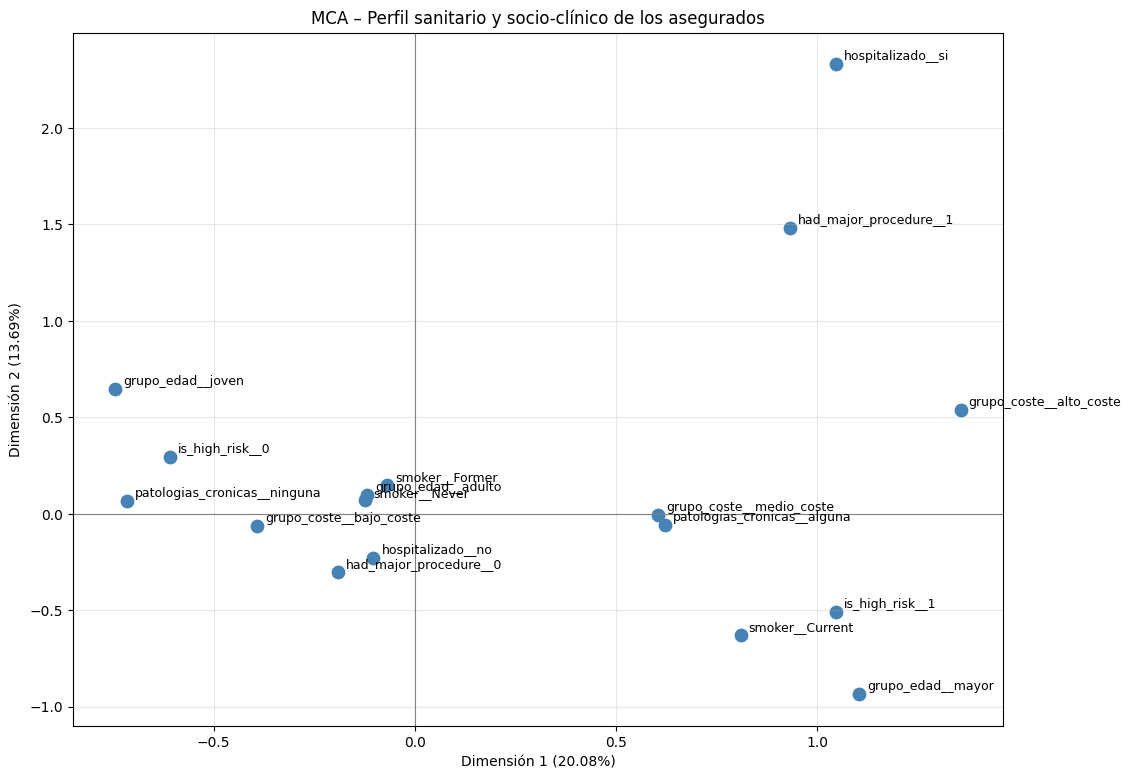

In [ ]:

active_vars = [
    'grupo_edad',
    'patologias_cronicas',
    'hospitalizado',
    'had_major_procedure',
    'is_high_risk',
    'smoker',
    'grupo_coste'
]

df_mca = df[active_vars].copy()
df_mca = df_mca.astype('category')

print("Variables activas del MCA:")
display(pd.DataFrame(active_vars, columns=["Variable"]))

# 4. CÁLCULO DEL MCA

mca = prince.MCA(
    n_components=10,
    random_state=42,
    check_input=True
).fit(df_mca)

# 5. TABLA DE INERCIA Y AUTOVALORES

eigs = mca.eigenvalues_
pct = mca.percentage_of_variance_ 
pct_acum = mca.cumulative_percentage_of_variance_ 
inercia_df = pd.DataFrame({
    "Autovalor": eigs,
    "% Varianza": pct,
    "% Acumulada": pct_acum
})

inercia_df.index = [f"Dim {i+1}" for i in range(len(eigs))]

print("RESUMEN DE INERCIA")
display(inercia_df.round(4))

print(f"Inercia total: {mca.total_inertia_:.4f}")

# 6. COORDENADAS DE LAS CATEGORÍAS

coords = mca.column_coordinates(df_mca)
coords.index.name = "Categoría"

print("COORDENADAS DE LAS CATEGORÍAS")
display(coords.round(4))

# 7. CONTRIBUCIONES DE LAS CATEGORÍAS

try:
    contrib = mca.column_contributions_
    contrib.index.name = "Categoría"
    print("\n CONTRIBUCIONES DE LAS CATEGORÍAS")
    display(contrib.round(4))
except AttributeError:
    print("La versión de prince no soporta 'column_contributions_'.")

# 8. MAPA FACTORIAL CON % EN LOS EJES

var_dim1 = mca.percentage_of_variance_[0] 
var_dim2 = mca.percentage_of_variance_[1] 

plt.figure(figsize=(12, 9))

for label, x, y in zip(coords.index, coords[0], coords[1]):
    plt.scatter(x, y, s=80, color="steelblue")
    plt.text(x + 0.02, y + 0.02, label, fontsize=9)

plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("MCA – Perfil sanitario y socio-clínico de los asegurados")
plt.xlabel(f"Dimensión 1 ({var_dim1:.2f}%)")
plt.ylabel(f"Dimensión 2 ({var_dim2:.2f}%)")
plt.grid(alpha=0.3)
plt.show()


In [12]:
import prince
help(prince.MCA)


Help on class MCA in module prince.mca:

class MCA(sklearn.base.BaseEstimator, sklearn.base.TransformerMixin, prince.ca.CA)
 |  MCA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=None, engine='sklearn', one_hot=True, one_hot_prefix_sep='__', one_hot_columns_to_drop=None, correction=None)
 |
 |  Method resolution order:
 |      MCA
 |      sklearn.base.BaseEstimator
 |      sklearn.utils._repr_html.base.ReprHTMLMixin
 |      sklearn.utils._repr_html.base._HTMLDocumentationLinkMixin
 |      sklearn.utils._metadata_requests._MetadataRequester
 |      sklearn.base.TransformerMixin
 |      sklearn.utils._set_output._SetOutputMixin
 |      prince.ca.CA
 |      prince.utils.EigenvaluesMixin
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, n_components=2, n_iter=10, copy=True, check_input=True, random_state=None, engine='sklearn', one_hot=True, one_hot_prefix_sep='__', one_hot_columns_to_drop=None, correction=None)
 |      Initialize self.  See h

In [13]:
for comando in dir(mca):
    if "inertia" in comando or "eigen" in comando or "variance" in comando:
        print(comando)

_eigenvalues_summary
cumulative_percentage_of_variance_
eigenvalues_
eigenvalues_summary
percentage_of_variance_
total_inertia_


In [15]:
import seaborn as sns
def resumen_faltantes(df):
    faltantes = df.isna().sum()
    pct_faltantes = (faltantes / len(df)) * 100
    resumen = pd.DataFrame({
        'Faltantes': faltantes,
        '% Faltantes': pct_faltantes
    })
    resumen = resumen[resumen['Faltantes'] > 0].sort_values(by='Faltantes', ascending=False)    
    return resumen

def faltates_filas(df):
    num_faltantes = df.isna().sum(axis=1)
    resumen = num_faltantes.value_counts().sort_index()
    resumen_pct = (resumen / len(df)) * 100
    resumen_filas = pd.DataFrame({
        'Número de Faltantes': resumen.index,
        'Cantidad de Filas': resumen.values,
        '% Filas': resumen_pct.values
    })
    return resumen_filas
def heatmap_faltantes(df):
    import seaborn as sns
    sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Mapa de Calor de Valores Faltantes')
    plt.xlabel('Variables')
    plt.ylabel('Observaciones')
    plt.show()

,Faltantes,% Faltantes


,Número de Faltantes,Cantidad de Filas,% Filas
0,0,100000,100.0


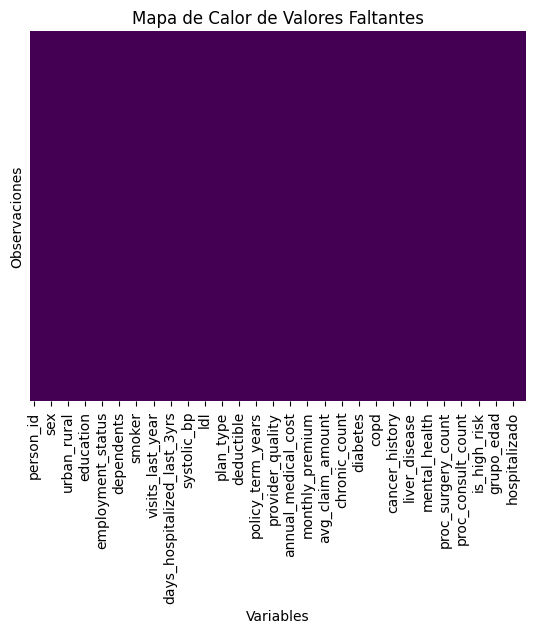

In [16]:
display(resumen_faltantes(df))
display(faltates_filas(df))
heatmap_faltantes(df)




In [19]:
from prettytable import PrettyTable
def mostrar_tabla_prettytable(df):
    tabla = PrettyTable()
    tabla.field_names = df.columns.tolist()
    for _, row in df.iterrows():
        tabla.add_row(row.tolist())
    print(tabla)

mostrar_tabla_prettytable(inercia_df.round(4))


+-----------+------------+-------------+
| Autovalor | % Varianza | % Acumulada |
+-----------+------------+-------------+
|   0.2869  |  20.0818   |   20.0818   |
|   0.1955  |  13.6854   |   33.7672   |
|   0.1495  |  10.4649   |   44.2321   |
|   0.1452  |   10.167   |    54.399   |
|   0.1425  |   9.9733   |   64.3724   |
|   0.1413  |   9.8914   |   74.2638   |
|   0.1295  |   9.065    |   83.3288   |
|   0.1103  |   7.7216   |   91.0504   |
|   0.0818  |   5.7287   |    96.779   |
|   0.046   |   3.221    |    100.0    |
+-----------+------------+-------------+
